### EDA for Netflix.csv

- First look at the data, to get a quick overview
- Data profiling
- Missing values
- Duplicate check
- Descriptive statiscs
- Univariant analys
- Uivariant analys

In [79]:
import pandas as pd

import duckdb
import matplotlib.pyplot as plt

INPUT_FILE = "../data/raw/netflix.csv"

pd.set_option('display.max_colwidth', None)

In [80]:
netflix = pd.read_csv(INPUT_FILE)

#### 1. First look at the data

In [81]:
netflix.head(5)

,Unnamed: 0,country_name,country_iso2,week,country_category,country_weekly_rank,show_title,season_title,country_cumulative_weeks_in_top_10,global_category,global_weekly_rank,global_weekly_hours_viewed,runtime,global_weekly_views,global_cumulative_weeks_in_top_10
0,0,Argentina,AR,2026-03-15,Films,1,War Machine,NaN,2,Films (English),1.0,80600000.0,109.002,44400000.0,2.0
1,1,Argentina,AR,2026-03-15,Films,2,Strangers in the Park,NaN,2,Films (Non-English),10.0,1600000.0,115.998,800000.0,2.0
2,2,Argentina,AR,2026-03-15,Films,3,Joker: Folie à Deux,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN
3,3,Argentina,AR,2026-03-15,Films,4,Trolls Band Together,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN
4,4,Argentina,AR,2026-03-15,Films,5,Double Jeopardy,NaN,1,Films (English),5.0,6200000.0,106.002,3500000.0,1.0


In [82]:
# Removing first column
netflix = netflix.drop("Unnamed: 0", axis='columns')
netflix

,country_name,country_iso2,week,country_category,country_weekly_rank,show_title,season_title,country_cumulative_weeks_in_top_10,global_category,global_weekly_rank,global_weekly_hours_viewed,runtime,global_weekly_views,global_cumulative_weeks_in_top_10
0,Argentina,AR,2026-03-15,Films,1,War Machine,NaN,2,Films (English),1.0,80600000.0,109.002,44400000.0,2.0
1,Argentina,AR,2026-03-15,Films,2,Strangers in the Park,NaN,2,Films (Non-English),10.0,1600000.0,115.998,800000.0,2.0
2,Argentina,AR,2026-03-15,Films,3,Joker: Folie à Deux,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN
3,Argentina,AR,2026-03-15,Films,4,Trolls Band Together,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN
4,Argentina,AR,2026-03-15,Films,5,Double Jeopardy,NaN,1,Films (English),5.0,6200000.0,106.002,3500000.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
520466,Vietnam,VN,2021-07-04,TV,6,Reply 1988,Reply 1988: Season 1,1,NaN,NaN,NaN,NaN,NaN,NaN
520467,Vietnam,VN,2021-07-04,TV,7,"Nevertheless,","Nevertheless,: Limited Series",1,NaN,NaN,NaN,NaN,NaN,NaN
520468,Vietnam,VN,2021-07-04,TV,8,Too Hot to Handle,Too Hot to Handle: Season 2,1,TV (English),2.0,62150000.0,NaN,NaN,1.0
520469,Vietnam,VN,2021-07-04,TV,9,Record of Ragnarok,Record of Ragnarok: Season 1,1,TV (Non-English),10.0,9140000.0,NaN,NaN,1.0


#### 2. Data profiling

In [83]:
print(f"\nNumber of rows   : {netflix.shape[0]:,}")
print(f"Number of columns: {netflix.shape[1]}")
 
print("\nColumn overview (name + datatype):")
print(netflix.dtypes.to_string())
 
print("\nFirst 3 rows:")
print(netflix.head(3).to_string())


Number of rows   : 520,471
Number of columns: 14

Column overview (name + datatype):
country_name                           object
country_iso2                           object
week                                   object
country_category                       object
country_weekly_rank                     int64
show_title                             object
season_title                           object
country_cumulative_weeks_in_top_10      int64
global_category                        object
global_weekly_rank                    float64
global_weekly_hours_viewed            float64
runtime                               float64
global_weekly_views                   float64
global_cumulative_weeks_in_top_10     float64

First 3 rows:
  country_name country_iso2        week country_category  country_weekly_rank             show_title season_title  country_cumulative_weeks_in_top_10      global_category  global_weekly_rank  global_weekly_hours_viewed  runtime  global_weekly_views  globa

#### 3. Missing-values

In [84]:
print(f"Missing-values in the dataset: {netflix.isna().sum().sum()}")

print("Missing-values per column:")
netflix.isna().sum()

Missing-values in the dataset: 1448226
Missing-values per column:


country_name                               0
country_iso2                               0
week                                       0
country_category                           0
country_weekly_rank                        0
show_title                                 0
season_title                          238790
country_cumulative_weeks_in_top_10         0
global_category                       148348
global_weekly_rank                    148348
global_weekly_hours_viewed            148348
runtime                               308022
global_weekly_views                   308022
global_cumulative_weeks_in_top_10     148348
dtype: int64

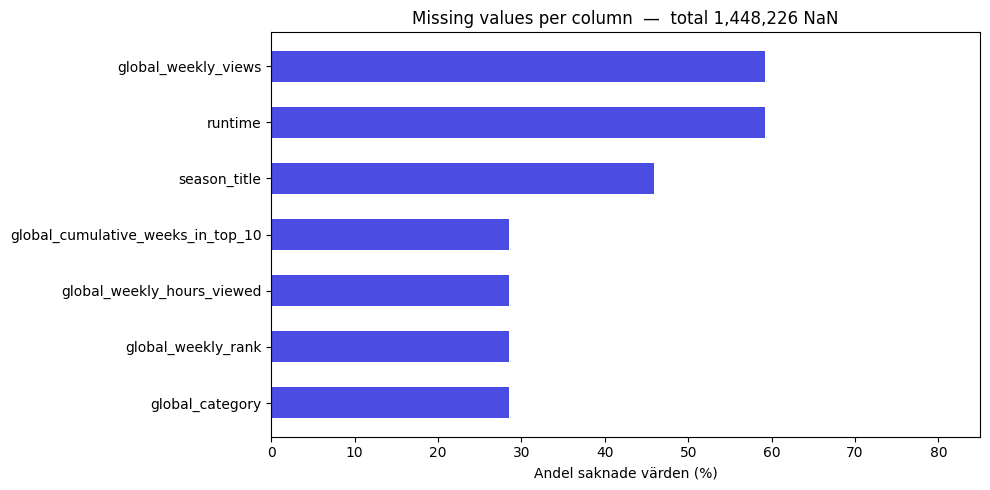

In [85]:
# Beräknar statistik för saknade värden (NaN)
null_counts = netflix.isnull().sum() # Räknar antal tomma celler per kolumn
null_pct = (null_counts / len(netflix) * 100).round(1) # Räknar ut andelen (%) och rundar till en decimal

# Skapar en ny tabell (DataFrame) med resultaten
null_df = pd.DataFrame({'nulls': null_counts, 'pct': null_pct})

# Filtrerar bort kolumner utan tomma värden och sortera efter lägst till högst andel
null_df = null_df[null_df['nulls'] > 0].sort_values('pct', ascending=True)

# Skapar själva figuren och axeln (ritytan)
fig, ax = plt.subplots(figsize=(10, 5))

# Skapa ett liggande stapeldiagram (barh)
# Använder kolumnnamn som etiketter och procent som längd på staplarna
ax.barh(null_df.index, null_df['pct'], color="#4A4CE2", height=0.55)

# Lägg till etikett på X-axeln och en titel
ax.set_xlabel('Andel saknade värden (%)')
ax.set_title(f"Missing values per column  —  total {netflix.isnull().sum().sum():,} NaN")

# Sätter gränsen för X-axeln upp till 85% för bättre överblick
ax.set_xlim(0, 85)

# Justerar layouten och visa diagrammet
plt.tight_layout()
plt.show()

#### 4. Duplicate check

In [86]:
duplicate = netflix.duplicated().sum()
print(f"\nNumber of duplicates: {duplicate}")


Number of duplicates: 0


#### 5. Descriptive statistics

In [87]:
netflix.describe()

,country_weekly_rank,country_cumulative_weeks_in_top_10,global_weekly_rank,global_weekly_hours_viewed,runtime,global_weekly_views,global_cumulative_weeks_in_top_10
count,520471.000000,520471.000000,372123.000000,3.721230e+05,212449.000000,2.124490e+05,372123.000000
mean,5.446822,3.646954,3.960161,3.426211e+07,274.835466,8.029263e+06,3.833671
std,2.887451,5.991701,2.667391,4.279279e+07,195.518602,8.378173e+06,4.675676
min,1.000000,1.000000,1.000000,8.000000e+05,0.000000,7.000000e+05,1.000000
25%,3.000000,1.000000,2.000000,1.239000e+07,108.000000,3.100000e+06,1.000000
50%,5.000000,2.000000,3.000000,2.220000e+07,238.998000,5.100000e+06,2.000000
75%,8.000000,4.000000,6.000000,3.974000e+07,409.002000,9.300000e+06,4.000000
max,10.000000,127.000000,10.000000,5.717600e+08,2854.998000,6.800000e+07,39.000000


Deskriptiv statistik (numeriska kolumner):
       country_weekly_rank  country_cumulative_weeks_in_top_10  global_weekly_rank  global_weekly_hours_viewed    runtime  global_weekly_views  global_cumulative_weeks_in_top_10
count            520471.00                           520471.00           372123.00                3.721230e+05  212449.00            212449.00                          372123.00
mean                  5.45                                3.65                3.96                3.426211e+07     274.84           8029263.49                               3.83
std                   2.89                                5.99                2.67                4.279279e+07     195.52           8378173.41                               4.68
min                   1.00                                1.00                1.00                8.000000e+05       0.00            700000.00                               1.00
25%                   3.00                                1.00     

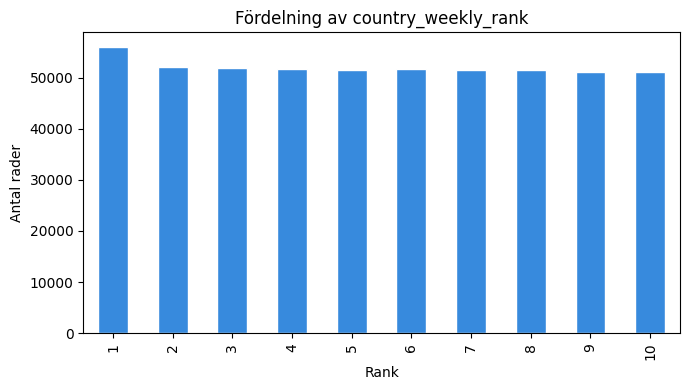

In [88]:
print("Deskriptiv statistik (numeriska kolumner):")
print(netflix.describe().round(2).to_string())

fig, ax = plt.subplots(figsize=(7, 4))

netflix["country_weekly_rank"].value_counts().sort_index().plot(
    kind="bar", ax=ax, color="#378ADD", edgecolor="white"
)
ax.set_title("Fördelning av country_weekly_rank")
ax.set_xlabel("Rank")
ax.set_ylabel("Antal rader")

plt.tight_layout()
plt.show()

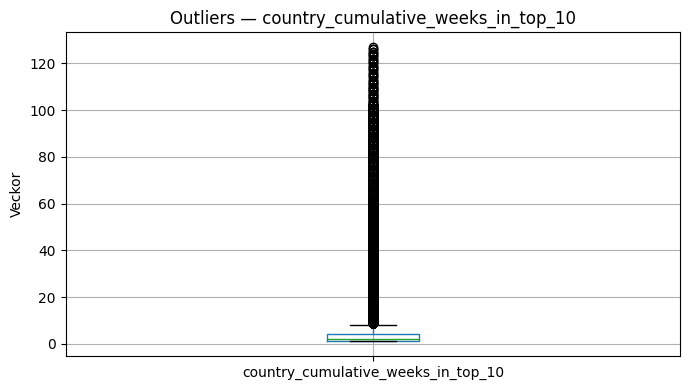

In [89]:
# Investigate outliers

fig, ax = plt.subplots(figsize=(7, 4))

netflix.boxplot(column="country_cumulative_weeks_in_top_10", ax=ax)
ax.set_title("Outliers — country_cumulative_weeks_in_top_10")
ax.set_ylabel("Veckor")

plt.tight_layout()
plt.show()

In [90]:
duckdb.sql("""
    SELECT show_title, country_name, country_cumulative_weeks_in_top_10
    FROM netflix
    ORDER BY country_cumulative_weeks_in_top_10 DESC
    LIMIT 5
""").df()

,show_title,country_name,country_cumulative_weeks_in_top_10
0,Money Heist,Pakistan,127
1,Money Heist,Pakistan,126
2,Lottie Dottie Chicken,Brazil,126
3,Lottie Dottie Chicken,Brazil,125
4,Money Heist,Pakistan,125


In [91]:
duckdb.sql(
    """
    SELECT show_title, global_cumulative_weeks_in_top_10
    FROM netflix
    ORDER BY global_cumulative_weeks_in_top_10 DESC
    LIMIT 5
    """).df()

,show_title,global_cumulative_weeks_in_top_10
0,KPop Demon Hunters,39.0
1,KPop Demon Hunters,39.0
2,KPop Demon Hunters,39.0
3,KPop Demon Hunters,39.0
4,KPop Demon Hunters,39.0


**Findings:** The queries above confirm that the merge was unsuccessful.
The global columns contain duplicated values, the same title appears
multiple times with identical global_cumulative_weeks_in_top_10,
which makes aggregations on global data unreliable.

#### 6. Univariant analys

In [92]:
# Unique values for column, country_name

unique_country = netflix['country_name'].nunique()
print(f"Unique countrys: {unique_country}")

netflix['country_name'].unique()

Unique countrys: 94


array(['Argentina', 'Australia', 'Austria', 'Bahamas', 'Bahrain',
       'Bangladesh', 'Belgium', 'Bolivia', 'Brazil', 'Bulgaria', 'Canada',
       'Chile', 'Colombia', 'Costa Rica', 'Croatia', 'Cyprus',
       'Czech Republic', 'Denmark', 'Dominican Republic', 'Ecuador',
       'Egypt', 'El Salvador', 'Estonia', 'Finland', 'France', 'Germany',
       'Greece', 'Guadeloupe', 'Guatemala', 'Honduras', 'Hong Kong',
       'Hungary', 'Iceland', 'India', 'Indonesia', 'Ireland', 'Israel',
       'Italy', 'Jamaica', 'Japan', 'Jordan', 'Kenya', 'Kuwait', 'Latvia',
       'Lebanon', 'Lithuania', 'Luxembourg', 'Malaysia', 'Maldives',
       'Malta', 'Martinique', 'Mauritius', 'Mexico', 'Morocco',
       'Netherlands', 'New Caledonia', 'New Zealand', 'Nicaragua',
       'Nigeria', 'Norway', 'Oman', 'Pakistan', 'Panama', 'Paraguay',
       'Peru', 'Philippines', 'Poland', 'Portugal', 'Qatar', 'Romania',
       'Russia', 'Réunion', 'Saudi Arabia', 'Serbia', 'Singapore',
       'Slovakia', 'Slovenia

In [93]:
# Unique values for column, country_category

print(f"Unique values: {netflix["country_category"].nunique()}")
netflix["country_category"].unique()


Unique values: 2


array(['Films', 'TV'], dtype=object)

In [94]:
duckdb.sql("""
           SELECT count(DISTINCT show_title) as unique_show_titles
           FROM netflix
           """).df()

,unique_show_titles
0,11060


In [95]:
duckdb.sql("""
           SELECT count(DISTINCT show_title) as unique_films
           FROM netflix
           WHERE country_category = 'Films'
           """).df()

,unique_films
0,7965


In [96]:
duckdb.sql("""
           SELECT count(DISTINCT show_title) as unique_tv_shows
           FROM netflix
           WHERE country_category = 'TV'
           """).df()

,unique_tv_shows
0,3204


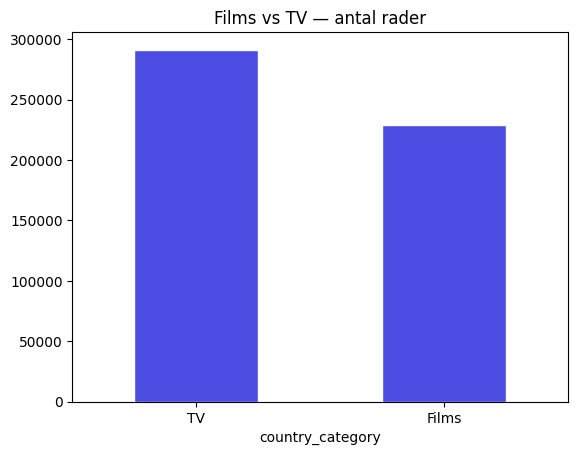

In [97]:
# Distribution Films vs TV-shows
netflix["country_category"].value_counts().plot(kind="bar", color="#4A4CE2", edgecolor="white")
plt.title("Films vs TV — antal rader")
plt.xticks(rotation=0)
plt.show()

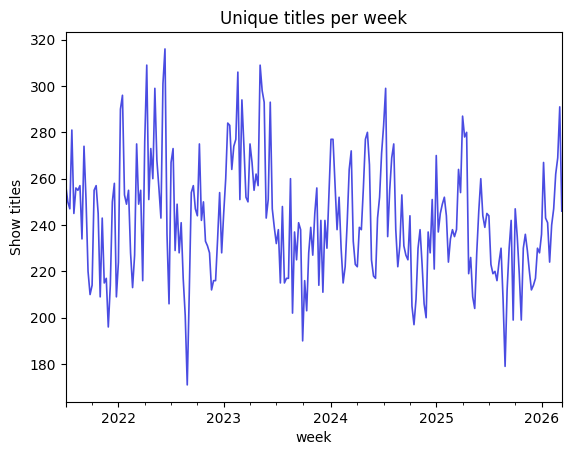

In [98]:
netflix["week"] = pd.to_datetime(netflix["week"])
netflix.groupby("week")["show_title"].nunique().plot(color="#4A4CE2", linewidth=1.2)
plt.title("Unique titles per week")
plt.xlabel("week")
plt.ylabel("Show titles")
plt.show()

#### 7. Bivariant analys 

In [99]:
# Shows average weeks in Top 10 for Films and TV-shows for Nordic countries

average_weeks = netflix[netflix["country_name"].isin(["Norway", "Sweden", "Iceland", "Denmark", "Finland"])].groupby(
    ["country_name", "country_category"]
)["country_cumulative_weeks_in_top_10"].mean().round().unstack()

average_weeks

country_category,Films,TV
country_name,,
Denmark,3.0,3.0
Finland,2.0,3.0
Iceland,3.0,3.0
Norway,3.0,3.0
Sweden,3.0,3.0


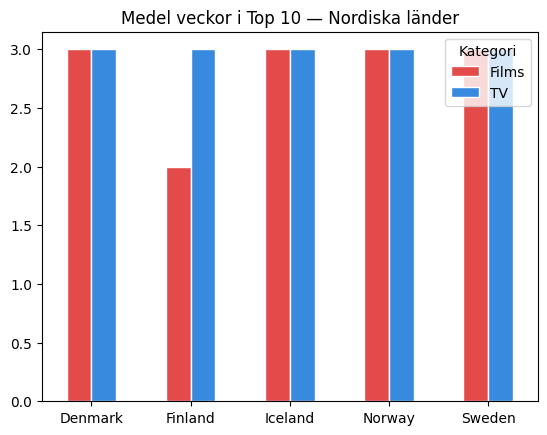

In [100]:
average_weeks.plot(kind="bar", color=["#E24B4A", "#378ADD"], edgecolor="white")
plt.title("Medel veckor i Top 10 — Nordiska länder")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend(title="Kategori")
plt.show()

## Summary of EDA findings

The dataset contains **520471 rows** and **14 columns**, covering
**94 countries** and **11,060 unique titles** from 2021-07-04 to 2026-03-15.

**Key findings:**

**Missing values**
The dataset has **1,448,226 NaN values**, all concentrated in the global columns.
global_weekly_rank, global_category, global_weekly_hours_viewed and
global_cumulative_weeks_in_top_10 are missing for a large portion of rows,
a direct consequence of the failed merge where country rows have no matching
global entry. runtime and global_weekly_views are missing even more broadly,
further confirming that the global part of the dataset is unreliable.

**Merge issue**
The merge of the country and global source files was unsuccessful.
Global values are duplicated across country rows, making any
aggregation on global columns unreliable. The dataset needs to be
separated into two independent tables before further analysis.

**Outliers**
country_cumulative_weeks_in_top_10 has a max of 127 weeks,
with most titles appearing only 1–2 weeks. The distribution is
heavily right-skewed.

**Distribution**
Films and TV are evenly split (~60/40), which is expected since
Netflix ranks them separately.

**Nordic countries**
TV-shows stay in the Top 10 longer than films across all Nordic
countries.